# Business Understanding

## Project Title
Credit Card Fraud Detection and Risk Scoring Using Machine Learning

## Business Context
Credit card fraud is a major challenge for banks, payment networks, fintech companies, and merchants. Large financial institutions process millions of transactions every day, and even a small percentage of fraudulent activity can result in significant financial losses, customer dissatisfaction, regulatory concerns, and reputational damage.

The business objective of this project is to develop a machine learning-based fraud detection solution that can identify high-risk credit card transactions and support faster decision-making. The model will assign a fraud risk prediction to each transaction so that the company can decide whether to approve, decline, or send the transaction for further review.

This project focuses on reducing fraud losses while also minimizing disruption for legitimate customers. In a real business environment, the system must balance fraud detection performance with customer experience, because incorrectly blocking genuine transactions can negatively impact customer trust.

## Business Problem
The company needs a reliable and scalable method to detect fraudulent credit card transactions from a high volume of daily transaction data. Manual review alone is not sufficient because transactions occur in real time and fraud patterns change quickly.

The problem is to identify suspicious transactions as early as possible while keeping false alerts low. A successful solution should help the business reduce financial losses, improve transaction security, protect customers, and support fraud operations teams with better risk-based decision-making.

## Data Science Problem
From a data science perspective, this is a supervised binary classification problem. The goal is to train a machine learning model that predicts whether a transaction is fraudulent or legitimate based on historical transaction features.

The target variable is Class:
- 0 = Legitimate transaction
- 1 = Fraudulent transaction

Because fraud cases are rare compared to normal transactions, this is an imbalanced classification problem. Therefore, the model will be evaluated using fraud-relevant metrics such as precision, recall, F1-score, ROC-AUC, and Precision-Recall AUC instead of relying only on accuracy.

## Stakeholders
The key stakeholders for this project include:

- Fraud Risk Team: Uses the model output to detect suspicious transactions and reduce fraud losses.
- Data Science Team: Builds, validates, and improves the fraud detection model.
- Fraud Operations Team: Reviews suspicious transactions flagged by the model.
- Customer Experience Team: Ensures that genuine customers are not unnecessarily blocked.
- Compliance and Risk Management Team: Ensures the fraud detection process is explainable, fair, and aligned with company policies.
- Business Leadership: Uses project outcomes to measure financial impact, operational efficiency, and risk reduction.

## Business Objective
The objective is to build a fraud risk scoring model that supports transaction-level decision-making by identifying high-risk transactions, reducing fraud-related losses, improving operational efficiency, and maintaining a smooth customer experience.

## Business Trade-Off
The fraud detection model must balance two types of business risk:

False Negative:
A fraudulent transaction is predicted as legitimate. This causes direct financial loss to the company or customer.

False Positive:
A legitimate transaction is predicted as fraudulent. This may block a genuine customer, create inconvenience, increase manual review workload, and reduce customer satisfaction.

In this project, false negatives are usually more costly because missed fraud can result in financial loss. However, false positives must also be controlled to avoid harming the customer experience.

## Project Scope
The scope of this project includes data understanding, exploratory data analysis, preprocessing, handling class imbalance, model training, model evaluation, and business interpretation of results.

The project will compare multiple machine learning models, including Logistic Regression as a baseline model and advanced models such as Random Forest and XGBoost. The final model will be selected based on fraud-specific evaluation metrics and business trade-offs.

## Out of Scope
This project does not include real-time production deployment, live transaction blocking, customer notification systems, or regulatory reporting automation. The focus is on building and evaluating a machine learning model using historical transaction data.

## Success Criteria
The project will be considered successful if the model can:

1. Detect a high percentage of actual fraudulent transactions.
2. Maintain a reasonable precision to avoid too many false alerts.
3. Perform better than a simple baseline model.
4. Provide interpretable results that can support fraud investigation.
5. Help the business understand the trade-off between fraud loss reduction and customer experience.

In [303]:
#Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [304]:
#lets load the dataset
df = pd.read_csv(r"C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection\data\creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [305]:
df.shape

(284807, 31)

In [306]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#The target variable `Class` shows whether a transaction is legitimate or fraudulent.
# Class 0 represents legitimate transactions.
# Class 1 represents fraudulent transactions.

#The dataset contains 284,315 legitimate transactions and 492 fraudulent transactions. This shows that the dataset is highly imbalanced, because fraud transactions represent only a very small percentage of the total data.

#This imbalance is a key challenge in fraud detection because a model can achieve high accuracy by predicting most transactions as legitimate, but still fail to detect actual fraud cases.

In [307]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [309]:
df.isnull().sum().sum()

np.int64(0)

#The dataset does not contain any missing values. This means all transaction records have complete information across all columns.

In [310]:
df.duplicated().sum()

np.int64(1081)

#The dataset contains 1,081 duplicate rows. These duplicate records will be reviewed during the data preprocessing stage before deciding whether to remove them.

In [311]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#The descriptive statistics show that transaction amounts vary widely, with an average transaction amount of about $88.35 and a maximum transaction amount of $25,691.16. The target variable mean is approximately 0.0017, confirming that fraudulent transactions represent a very small portion of the dataset. This supports the earlier finding that the dataset is highly imbalanced.

In [312]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

#The transaction amount shows a wide range of values. The average transaction amount is about $88.35, while the median transaction amount is $22.00. This indicates that most transactions are relatively small, but a few large transactions increase the overall average. The maximum transaction amount is $25,691.16.

In [313]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

#The `Time` column represents the number of seconds elapsed between each transaction and the first transaction in the dataset. The minimum time is 0 seconds and the maximum time is 172,792 seconds, which indicates that the dataset covers approximately two days of transaction activity.

In [314]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

#The target variable distribution shows that 99.83% of transactions are legitimate, while only 0.17% are fraudulent. This confirms that the dataset is highly imbalanced. Because of this imbalance, accuracy alone is not a reliable metric for model evaluation. The project will focus on fraud-specific metrics such as precision, recall, F1-score, ROC-AUC, and Precision-Recall AUC.

In [315]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

#The dataset contains 284,315 legitimate transactions and 492 fraudulent transactions. Fraud cases represent only 0.17% of the dataset, which confirms a severe class imbalance. This imbalance must be handled carefully during modeling and evaluation.

In [316]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#The first five rows show that the dataset contains numerical transaction features, transaction amount, time, and the target column `Class`. The anonymized columns `V1` to `V28` are transformed numerical features. The `Class` column indicates whether the transaction is legitimate or fraudulent.

In [317]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


#The last five rows confirm that the dataset continues with the same structure: Time, anonymized features V1 to V28, Amount, and Class. The final Time value is 172,792 seconds, which supports that the dataset covers approximately two days of transactions.

In [318]:
fraud_data = df[df['Class'] == 1]
fraud_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1


#The fraud-only sample shows that fraudulent transactions can have different transaction amounts, including very small or zero-dollar amounts. This suggests that fraud detection cannot rely only on transaction amount. The model needs to learn patterns from multiple features, including the anonymized variables V1 to V28.

In [319]:
normal_data = df[df['Class'] == 0]
normal_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


#The dataset was separated into two groups: fraudulent transactions and legitimate transactions. This allows us to compare transaction behavior between fraud and normal activity during exploratory data analysis.

In [320]:
fraud_data.shape

(492, 31)

#The fraud subset contains 492 transactions and 31 columns. These are the transactions where the target variable `Class` is equal to 1.

In [321]:
normal_data.shape

(284315, 31)

#The normal transaction subset contains 284,315 transactions and 31 columns. These are the transactions where the target variable `Class` is equal to 0.

In [322]:
fraud_data['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

#For fraudulent transactions, the average transaction amount is $122.21, while the median is only $9.25. This shows that many fraud transactions are small, even though some fraud amounts are much larger. The maximum fraud transaction amount is $2,125.87.

In [323]:
normal_data['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

#For legitimate transactions, the average transaction amount is $88.29 and the median transaction amount is $22.00. Compared with fraud transactions, the average fraud amount is higher, but the median fraud amount is lower. This suggests that fraud transactions are not always high-value transactions and can often occur in small amounts.

In [324]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


#The amount comparison shows that fraudulent transactions have a higher average amount than legitimate transactions. However, the median fraud amount is lower than the median normal amount. This suggests that many fraud transactions are small, and fraud detection should not rely only on transaction amount.

In [325]:
df.groupby('Class')['Time'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


#The time comparison shows that fraudulent transactions occurred throughout the dataset period. The average time for fraud transactions is lower than the average time for legitimate transactions, suggesting that fraud activity appears slightly earlier in the dataset. However, further visualization is needed before making strong conclusions.

In [326]:
df[['Time', 'Amount', 'Class']].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


#The summary of Time, Amount, and Class shows that the dataset contains 284,807 transactions. The average transaction amount is $88.35, while the median transaction amount is $22.00, indicating that most transactions are small but some large transactions increase the average. The Class mean is 0.001727, confirming that fraudulent transactions are extremely rare in the dataset.

In [327]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

#The unique value check shows that the `Class` column has two unique values: 0 and 1. This confirms that the project is a binary classification problem. The anonymized features V1 to V28 contain many unique numerical values, which indicates that they are continuous numerical features.

In [328]:
df['Class'].unique()

array([0, 1])

#The `Class` column contains only two unique values: 0 and 1. This confirms that the target variable is correctly formatted for binary classification.

In [329]:
df['Class'].dtype

dtype('int64')

#The target variable `Class` is stored as an integer data type. This is suitable for machine learning because the labels are numeric: 0 for legitimate transactions and 1 for fraudulent transactions.

In [330]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

#All columns in the dataset are numeric. The input features `Time`, `V1` to `V28`, and `Amount` are stored as float values, while the target variable `Class` is stored as an integer. Since there are no categorical text columns, no encoding is required at this stage.

In [331]:
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
54243,46355.0,-1.807434,-0.703867,1.461876,-0.718608,0.151694,-0.208499,-0.760849,0.843176,0.744871,...,-0.063440,-0.462635,-0.000857,-0.404736,0.010069,0.854741,0.095805,-0.185576,46.91,0
243579,151983.0,1.986406,-2.052257,-0.012222,-1.236913,-2.166049,-0.091654,-1.703142,0.153376,-0.534312,...,-0.293817,-0.446301,0.323634,0.023200,-0.611264,-0.398232,0.037660,-0.028307,110.34,0
145229,86744.0,-1.699686,1.724423,0.679096,-1.456603,1.527399,-0.768601,2.587819,-3.072652,3.414520,...,-0.357925,-0.768204,-0.141984,-0.130186,-0.211543,-0.084010,-0.342131,-1.318202,9.85,0
198671,132599.0,-0.461520,1.394655,-0.999287,-0.761190,0.862400,-0.295354,0.495652,0.501520,-0.315138,...,-0.292915,-0.770971,0.092433,0.124003,-0.333162,0.127981,0.211414,0.058718,4.46,0
167966,118993.0,2.136121,-0.712413,-1.072575,-0.525985,-0.978521,-1.135911,-0.929196,-0.131874,0.182461,...,0.230180,0.719862,0.110329,-0.098136,-0.174570,-0.086478,0.023743,-0.012868,19.95,0


#A random sample of five transactions shows mostly legitimate transactions. This is expected because the dataset is highly imbalanced, with legitimate transactions representing 99.83% of all records.

chapter 2

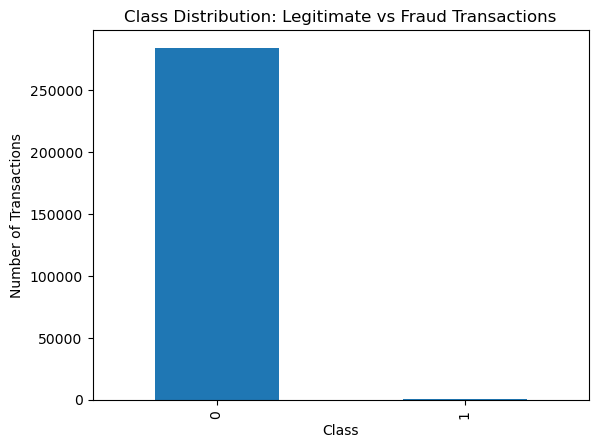

In [332]:
df['Class'].value_counts().plot(kind='bar')

plt.title('Class Distribution: Legitimate vs Fraud Transactions')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()

The class distribution chart shows a severe imbalance in the dataset. Legitimate transactions make up almost all of the data, while fraudulent transactions represent only a very small fraction. This confirms that fraud detection is a highly imbalanced classification problem, and model evaluation should focus on precision, recall, F1-score, ROC-AUC, and PR-AUC rather than accuracy alone.

In [333]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

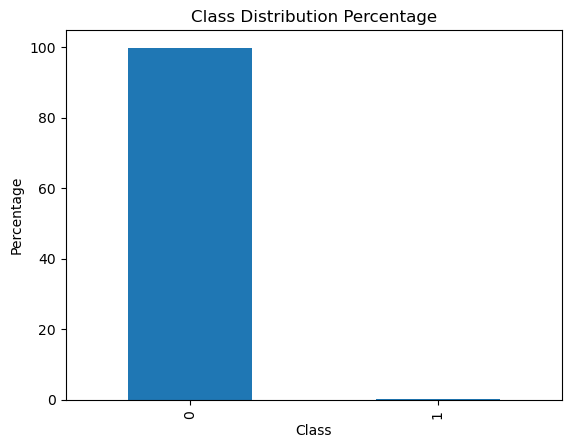

In [334]:
class_percentage = df['Class'].value_counts(normalize=True) * 100

class_percentage.plot(kind='bar')

plt.title('Class Distribution Percentage')
plt.xlabel('Class')
plt.ylabel('Percentage')
plt.show()

#The percentage distribution chart shows that legitimate transactions account for approximately 99.83% of the dataset, while fraudulent transactions account for only 0.17%. This confirms that the dataset is severely imbalanced. In fraud detection, this imbalance is expected because fraudulent activity is rare compared to normal customer transactions.

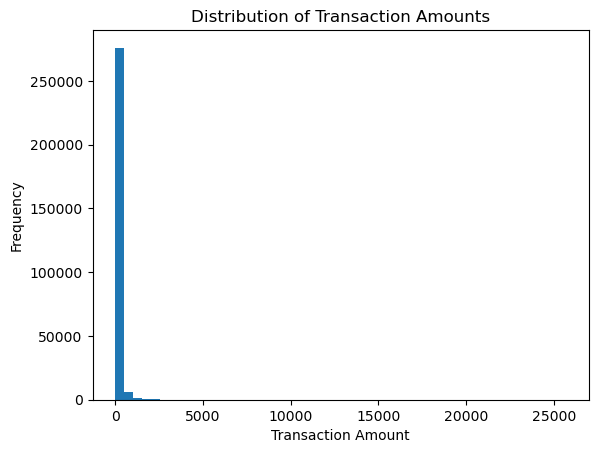

In [335]:
plt.hist(df['Amount'], bins=50)

plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

The transaction amount distribution is highly right-skewed. Most transactions are small, while a small number of transactions have very large amounts. This indicates the presence of high-value outliers in the Amount column.

In [336]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

The average transaction amount for legitimate transactions is $88.29, while the average transaction amount for fraudulent transactions is $122.21. This shows that fraud transactions have a higher average amount. However, the median fraud amount is much lower, which suggests that many fraud transactions are still small.

In [337]:
df.groupby('Class')['Amount'].median()

Class
0    22.00
1     9.25
Name: Amount, dtype: float64

The median transaction amount for legitimate transactions is $22.00, while the median transaction amount for fraudulent transactions is $9.25. This shows that many fraud transactions are small. Therefore, transaction amount alone is not enough to detect fraud.

In [338]:
df.groupby('Class')['Amount'].max()

Class
0    25691.16
1     2125.87
Name: Amount, dtype: float64

The maximum legitimate transaction amount is $25,691.16, while the maximum fraudulent transaction amount is $2,125.87. This shows that the largest transactions are not necessarily fraudulent. Therefore, fraud detection should consider multiple transaction patterns, not only transaction amount.

In [339]:
df.groupby('Class')['Amount'].min()

Class
0    0.0
1    0.0
Name: Amount, dtype: float64

The minimum transaction amount for both legitimate and fraudulent transactions is $0.00. This shows that zero-amount transactions exist in both classes, so transaction amount alone cannot determine whether a transaction is fraudulent.

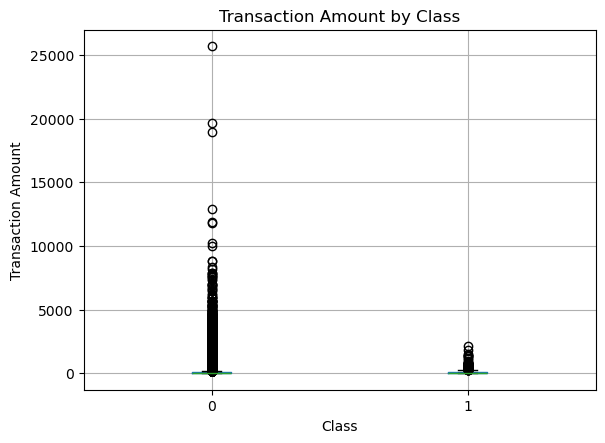

In [340]:
df.boxplot(column='Amount', by='Class')

plt.title('Transaction Amount by Class')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')
plt.show()

The boxplot shows that legitimate transactions contain many high-value outliers, while fraudulent transactions generally have lower maximum transaction amounts. This confirms that high transaction amount alone is not a reliable fraud indicator. A machine learning model should use multiple features rather than relying only on transaction amount.

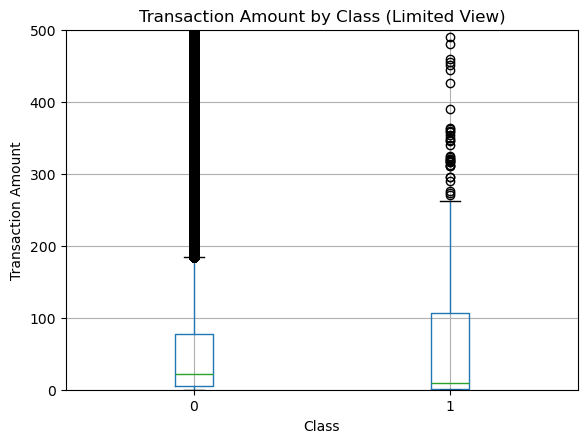

In [341]:
df.boxplot(column='Amount', by='Class')

plt.title('Transaction Amount by Class (Limited View)')
plt.suptitle('')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')
plt.ylim(0, 500)
plt.show()

The limited boxplot provides a clearer view of transaction amounts between $0 and $500. It shows that many fraudulent transactions have small amounts, with a lower median amount than legitimate transactions. However, fraud transactions also include some higher-value outliers. This reinforces that transaction amount alone is not enough to detect fraud.

In [342]:
df[df['Amount'] == 0]['Class'].value_counts()

Class
0    1798
1      27
Name: count, dtype: int64

The dataset contains zero-amount transactions in both classes. There are 1,798 legitimate zero-amount transactions and 27 fraudulent zero-amount transactions. This shows that zero-amount transactions are not automatically fraudulent, but they may still be useful to analyze as part of fraud behavior.

In [343]:
df[df['Amount'] == 0]['Class'].value_counts(normalize=True) * 100

Class
0    98.520548
1     1.479452
Name: proportion, dtype: float64

Among zero-amount transactions, approximately 1.48% are fraudulent. This is higher than the overall fraud rate of 0.17% in the full dataset. Although most zero-amount transactions are legitimate, zero-amount activity may still be useful as a potential fraud signal.

In [344]:
df['is_zero_amount'] = (df['Amount'] == 0).astype(int)
df[['Amount', 'is_zero_amount', 'Class']].head()

,Amount,is_zero_amount,Class
0,149.62,0,0
1,2.69,0,0
2,378.66,0,0
3,123.50,0,0
4,69.99,0,0


A new feature named `is_zero_amount` was created to identify transactions where the transaction amount is equal to $0.00. This feature is useful because zero-amount transactions showed a higher fraud rate than the overall dataset.

In [345]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'is_zero_amount'],
      dtype='object')

The new feature `is_zero_amount` was successfully added to the dataset. This column identifies whether a transaction amount is equal to zero.

In [346]:
df['is_zero_amount'].value_counts()

is_zero_amount
0    282982
1      1825
Name: count, dtype: int64

The `is_zero_amount` feature shows that 1,825 transactions have an amount equal to zero, while 282,982 transactions have a non-zero amount. This feature may help identify special transaction behavior related to fraud.

In [347]:
df.groupby('is_zero_amount')['Class'].mean() * 100

is_zero_amount
0    0.164321
1    1.479452
Name: Class, dtype: float64

The fraud rate for non-zero amount transactions is approximately 0.16%, while the fraud rate for zero-amount transactions is approximately 1.48%. This shows that zero-amount transactions have a higher fraud rate than non-zero transactions. Therefore, the `is_zero_amount` feature may provide useful information for fraud detection.

In [348]:
df['transaction_hour'] = (df['Time'] // 3600) % 24
df[['Time', 'transaction_hour', 'Class']].head()

,Time,transaction_hour,Class
0,0.0,0.0,0
1,0.0,0.0,0
2,1.0,0.0,0
3,1.0,0.0,0
4,2.0,0.0,0


A new feature named `transaction_hour` was created from the `Time` column. Since the original `Time` column is measured in seconds, it was converted into an approximate hour of the day. This feature may help identify whether fraudulent transactions are more common during certain hours.

In [349]:
df[['Time', 'transaction_hour', 'Class']].sample(10)

,Time,transaction_hour,Class
109732,71518.0,19.0,0
135428,81249.0,22.0,0
126037,77905.0,21.0,0
188569,128031.0,11.0,0
2036,1578.0,0.0,0
143556,85441.0,23.0,0
190800,128989.0,11.0,0
85430,60770.0,16.0,0
121983,76392.0,21.0,0
81930,59165.0,16.0,0


The `transaction_hour` feature was checked using a random sample. The values range between 0 and 23, showing that the transaction time was successfully converted into an approximate hour-of-day feature.

In [350]:
df['transaction_hour'].value_counts().sort_index()

transaction_hour
0.0      7695
1.0      4220
2.0      3328
3.0      3492
4.0      2209
5.0      2990
6.0      4101
7.0      7243
8.0     10276
9.0     15838
10.0    16598
11.0    16856
12.0    15420
13.0    15365
14.0    16570
15.0    16461
16.0    16453
17.0    16166
18.0    17039
19.0    15649
20.0    16756
21.0    17703
22.0    15441
23.0    10938
Name: count, dtype: int64

The transaction count by hour shows that transaction activity is not evenly distributed across the day. Some hours have more transaction volume than others. Hour 21 has the highest transaction count in this dataset, while hour 4 has one of the lowest transaction counts.

In [351]:
df[df['Class'] == 1]['transaction_hour'].value_counts().sort_index()

transaction_hour
0.0      6
1.0     10
2.0     57
3.0     17
4.0     23
5.0     11
6.0      9
7.0     23
8.0      9
9.0     16
10.0     8
11.0    53
12.0    17
13.0    17
14.0    23
15.0    26
16.0    22
17.0    29
18.0    33
19.0    19
20.0    18
21.0    16
22.0     9
23.0    21
Name: count, dtype: int64

Fraud transaction counts vary across different transaction hours. The highest fraud counts appear around hour 2 and hour 11. However, fraud count alone is not enough because some hours may have more total transaction volume. Therefore, fraud rate by hour should also be calculated.

In [352]:
df.groupby('transaction_hour')['Class'].mean() * 100

transaction_hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64

The fraud rate by transaction hour shows that fraud is not evenly distributed across time. Hour 2 has the highest fraud rate at approximately 1.71%, followed by hour 4 at approximately 1.04%. Since the overall fraud rate is only 0.17%, these higher hourly fraud rates suggest that transaction time may provide useful information for fraud detection.

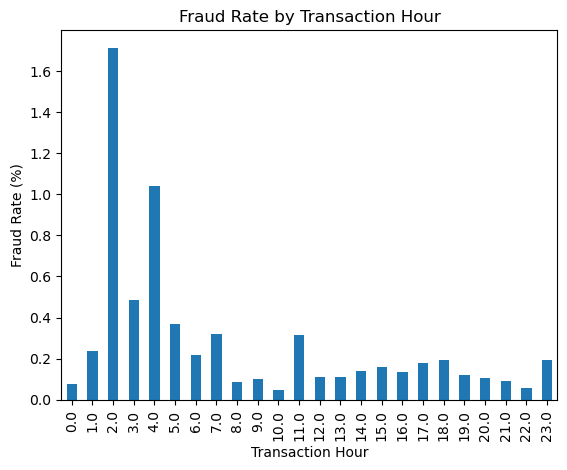

In [353]:
fraud_rate_by_hour = df.groupby('transaction_hour')['Class'].mean() * 100

fraud_rate_by_hour.plot(kind='bar')

plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Fraud Rate (%)')
plt.show()

The fraud rate by transaction hour chart shows that fraud risk varies by hour. Hour 2 has the highest fraud rate, followed by hour 4. This suggests that time-based behavior may provide useful information for fraud detection. However, because the original Time column is relative to the first transaction in the dataset, this feature should be interpreted carefully.

In [354]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'is_zero_amount', 'transaction_hour'],
      dtype='object')

Two new features were added to the dataset: `is_zero_amount` and `transaction_hour`. The `is_zero_amount` feature identifies zero-dollar transactions, while `transaction_hour` converts the original Time column into an approximate hour-based feature. These features may help capture fraud-related transaction behavior.

In [355]:
df.shape

(284807, 33)

After feature engineering, the dataset contains 284,807 rows and 33 columns. Two new features were added: `is_zero_amount` and `transaction_hour`.

In [356]:
df.groupby('is_zero_amount')['Class'].mean() * 100

is_zero_amount
0    0.164321
1    1.479452
Name: Class, dtype: float64

The fraud rate for zero-amount transactions is approximately 1.48%, compared to 0.16% for non-zero amount transactions. This suggests that zero-amount transactions have a higher fraud risk and that the `is_zero_amount` feature may be useful for fraud prediction.

In [357]:
df.groupby('transaction_hour')['Class'].mean() * 100

transaction_hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64

The fraud rate by transaction hour shows that fraud risk varies across time. Hour 2 has the highest fraud rate at approximately 1.71%, followed by hour 4 at approximately 1.04%. Since the overall fraud rate is only 0.17%, this suggests that transaction time may provide useful fraud-related information. However, this feature should be used together with other transaction features, not as a standalone rule.

In [358]:
summary_table = pd.DataFrame({
    'Metric': [
        'Total Transactions',
        'Normal Transactions',
        'Fraud Transactions',
        'Fraud Percentage',
        'Missing Values',
        'Duplicate Rows',
        'Average Transaction Amount',
        'Median Transaction Amount',
        'Maximum Transaction Amount',
        'Zero Amount Transactions'
    ],
    'Value': [
        df.shape[0],
        df['Class'].value_counts()[0],
        df['Class'].value_counts()[1],
        round(df['Class'].mean() * 100, 4),
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        round(df['Amount'].mean(), 2),
        round(df['Amount'].median(), 2),
        round(df['Amount'].max(), 2),
        df['is_zero_amount'].sum()
    ]
})

summary_table

,Metric,Value
0,Total Transactions,284807.0000
1,Normal Transactions,284315.0000
2,Fraud Transactions,492.0000
3,Fraud Percentage,0.1727
4,Missing Values,0.0000
5,Duplicate Rows,1081.0000
6,Average Transaction Amount,88.3500
7,Median Transaction Amount,22.0000
8,Maximum Transaction Amount,25691.1600
9,Zero Amount Transactions,1825.0000


The EDA summary table provides a high-level overview of the dataset. The dataset contains 284,807 transactions, including 492 fraudulent transactions. Fraud represents only 0.1727% of the data, confirming a severe class imbalance. There are no missing values, but 1,081 duplicate rows were identified. The average transaction amount is $88.35, while the median transaction amount is $22.00, showing that most transactions are relatively small but some large transactions exist.

In [359]:
summary_table.to_csv("eda_summary_table.csv", index=False)

## EDA Conclusion

The exploratory data analysis shows that this dataset is highly imbalanced, with only 492 fraudulent transactions out of 284,807 total transactions. Fraud represents approximately 0.17% of the dataset, which means accuracy alone will not be a reliable metric for model evaluation.

The dataset does not contain missing values, but it includes 1,081 duplicate rows that will need to be reviewed during preprocessing. Transaction amounts are highly right-skewed, with most transactions being small and a few very large transactions increasing the average amount.

The comparison between legitimate and fraudulent transactions shows that fraud is not always associated with high transaction amounts. Many fraudulent transactions are small, and some even have zero transaction amount. Zero-amount transactions also showed a higher fraud rate than the overall dataset.

Time-based analysis showed that fraud rates vary by transaction hour, with some hours having higher fraud rates than others. Because of this, engineered features such as `is_zero_amount` and `transaction_hour` may be useful for fraud detection.

Overall, the EDA confirms that this is a challenging fraud detection problem because fraud cases are rare, transaction patterns are complex, and simple rules based only on amount or time are not sufficient.

Data Preprocessing

In [360]:
df.shape

(284807, 33)

In [361]:
df_model = df.copy()

In [362]:
df_model.shape

(284807, 33)

In [363]:
df_model.duplicated().sum()

np.int64(1081)

In [364]:
df_model = df_model.drop_duplicates()

In [365]:
df_model.shape

(283726, 33)

Exact duplicate rows were removed from the modeling dataset. The dataset originally contained 284,807 rows, and after removing 1,081 duplicate records, the modeling dataset contains 283,726 rows.

In [366]:
df_model.duplicated().sum()

np.int64(0)

After removing duplicate rows, the dataset was checked again and no duplicate records remained.

In [367]:
df_model['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

After duplicate removal, the modeling dataset contains 283,253 legitimate transactions and 473 fraudulent transactions. The fraud class is still extremely rare, so the dataset remains highly imbalanced.

In [368]:
df_model['Class'].value_counts(normalize=True) * 100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

After duplicate removal, legitimate transactions represent approximately 99.83% of the data, while fraudulent transactions represent only 0.17%. This confirms that the dataset remains highly imbalanced and requires careful model evaluation.

In [369]:
X = df_model.drop('Class', axis=1)
y = df_model['Class']

In [370]:
X.shape, y.shape

((283726, 32), (283726,))

The dataset was separated into input features and target variable. The feature matrix `X` contains 283,726 rows and 32 columns, while the target variable `y` contains 283,726 labels. The target variable is `Class`, where 0 represents legitimate transactions and 1 represents fraudulent transactions.

In [371]:
X.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'is_zero_amount', 'transaction_hour'],
      dtype='object')

The feature matrix `X` contains the original transaction features, including `Time`, `V1` to `V28`, and `Amount`, along with two engineered features: `is_zero_amount` and `transaction_hour`. The target variable `Class` was removed from `X` and stored separately in `y`.

In [372]:
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

The target variable `y` contains 283,253 legitimate transaction labels and 473 fraudulent transaction labels after duplicate removal. This confirms that the target variable was separated correctly and that the dataset remains highly imbalanced.

In [373]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

In [374]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((226980, 32), (56746, 32), (226980,), (56746,))

The dataset was split into training and testing sets using an 80/20 split. Stratified sampling was used to preserve the same fraud-to-normal transaction ratio in both sets. This is important because the dataset is highly imbalanced.

In [375]:
y_train.value_counts()

Class
0    226602
1       378
Name: count, dtype: int64

The training set contains 226,602 legitimate transactions and 378 fraudulent transactions. Fraud remains rare in the training data, which reflects the real-world imbalance in credit card fraud detection.

In [376]:
y_test.value_counts()

Class
0    56651
1       95
Name: count, dtype: int64

The testing set contains 56,651 legitimate transactions and 95 fraudulent transactions. Stratified splitting helped preserve the original class imbalance in the test data, making the evaluation more realistic.

In [377]:
print("Train fraud percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest fraud percentage:")
print(y_test.value_counts(normalize=True) * 100)

Train fraud percentage:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Test fraud percentage:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


The fraud percentage in the training set is approximately 0.1665%, while the fraud percentage in the testing set is approximately 0.1674%. These values are very close, confirming that stratified sampling successfully preserved the class distribution in both datasets.

In [378]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

In [379]:
X_train[['Time', 'Amount']].head()

,Time,Amount
226238,1.045499,-0.229434
134253,-0.298690,-0.331197
186465,0.678397,-0.298809
149493,-0.074929,-0.289247
18461,-1.376728,-0.261985


The `Time` and `Amount` features were scaled using StandardScaler. Scaling is important because these columns have different value ranges compared to the anonymized V1 to V28 features. The scaler was fitted only on the training data and then applied to the test data to avoid data leakage.

In [380]:
X_test[['Time', 'Amount']].head()

,Time,Amount
86568,-0.707761,-0.312846
251557,1.273872,-0.351745
20232,-1.348111,0.011771
68952,-0.878056,0.568071
191852,0.727104,-0.353901


The scaled test data confirms that the same StandardScaler transformation was applied to the test set. The scaler was fitted only on the training data and then used to transform the test data, which prevents data leakage.

In [381]:
X_train.shape, X_test.shape

((226980, 32), (56746, 32))

In [382]:
X_train.isnull().sum().sum(), X_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

After preprocessing, both the training and testing feature sets were checked for missing values. No missing values were found in either set.

In [383]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

log_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

A Logistic Regression model was trained as the baseline model. Because the dataset is highly imbalanced, `class_weight='balanced'` was used to give more importance to the minority fraud class during training.

In [384]:
y_pred_log = log_model.predict(X_test)

In [385]:
y_pred_log[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [386]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_log)

array([[55247,  1404],
       [   12,    83]])

The Logistic Regression baseline model correctly detected 83 fraudulent transactions and missed 12 fraudulent transactions. It also incorrectly flagged 1,404 legitimate transactions as fraud. This shows that the model has strong fraud detection ability, but it creates a relatively high number of false alerts.

In [387]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



The Logistic Regression baseline model achieved high recall for the fraud class, detecting 87% of actual fraud transactions. However, the fraud precision is low at 6%, meaning many legitimate transactions were incorrectly flagged as fraud. This indicates that the model is effective at catching fraud but creates a high number of false alerts. In a business setting, this model may be useful for fraud screening, but additional threshold tuning or advanced models are needed to reduce false positives.

In [388]:
from sklearn.metrics import roc_auc_score

y_prob_log = log_model.predict_proba(X_test)[:, 1]

roc_auc_log = roc_auc_score(y_test, y_prob_log)

roc_auc_log

np.float64(0.9684077672248086)

The Logistic Regression model achieved a ROC-AUC score of 0.9684, which indicates strong ability to separate fraudulent transactions from legitimate transactions. However, the low fraud precision shows that threshold tuning or more advanced models are needed to reduce false positives.

In [389]:
from sklearn.metrics import average_precision_score

pr_auc_log = average_precision_score(y_test, y_prob_log)

pr_auc_log

np.float64(0.6720972118731984)

The Logistic Regression model achieved a PR-AUC score of 0.6721. Since the dataset is highly imbalanced, PR-AUC is an important evaluation metric because it focuses on the trade-off between precision and recall for the fraud class. The result shows that the model has useful fraud detection ability, but precision improvement is still needed.

In [390]:
log_results = {
    'Model': 'Logistic Regression',
    'ROC_AUC': round(roc_auc_log, 4),
    'PR_AUC': round(pr_auc_log, 4),
    'Fraud Precision': 0.06,
    'Fraud Recall': 0.87,
    'Fraud F1': 0.10
}

log_results

{'Model': 'Logistic Regression',
 'ROC_AUC': np.float64(0.9684),
 'PR_AUC': np.float64(0.6721),
 'Fraud Precision': 0.06,
 'Fraud Recall': 0.87,
 'Fraud F1': 0.1}

The Logistic Regression model was used as the baseline model. It achieved a ROC-AUC score of 0.9684 and a PR-AUC score of 0.6721. The model detected 87% of fraud cases, but fraud precision was only 6%, meaning it generated many false positives. This baseline confirms that the dataset contains useful fraud signals, but a more advanced model or threshold tuning is needed to improve business usability.

In [391]:
results_table = pd.DataFrame([log_results])
results_table

,Model,ROC_AUC,PR_AUC,Fraud Precision,Fraud Recall,Fraud F1
0,Logistic Regression,0.9684,0.6721,0.06,0.87,0.1


The initial model results table was created to store and compare model performance. Logistic Regression is used as the baseline model. Additional models will be added to this table later for comparison.

In [392]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

A Random Forest Classifier was trained as the second model. Random Forest is an ensemble tree-based model that can capture non-linear relationships in the data. Because the dataset is highly imbalanced, `class_weight='balanced'` was used to give more importance to fraudulent transactions during training.

In [393]:
y_pred_rf = rf_model.predict(X_test)

In [394]:
y_pred_rf[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [395]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_rf)

array([[56649,     2],
       [   29,    66]])

In [396]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746



The Random Forest model achieved strong fraud precision of 97%, meaning that most transactions flagged as fraud were truly fraudulent. The fraud recall was 69%, meaning the model detected 69% of actual fraud cases but missed some fraudulent transactions. Compared with Logistic Regression, Random Forest greatly reduced false positives and achieved a stronger F1-score, but it had lower fraud recall.

In [397]:
from sklearn.metrics import roc_auc_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

roc_auc_rf

np.float64(0.919315587869959)

The Random Forest model achieved a ROC-AUC score of 0.9193. This indicates good fraud separation ability, although it is lower than the Logistic Regression ROC-AUC score. However, Random Forest produced much higher fraud precision and fewer false positives at the default classification threshold.

In [398]:
from sklearn.metrics import average_precision_score

pr_auc_rf = average_precision_score(y_test, y_prob_rf)

pr_auc_rf

np.float64(0.8020596695106028)

The Random Forest model achieved a PR-AUC score of 0.8021, which is higher than the Logistic Regression PR-AUC score of 0.6721. Since PR-AUC is especially important for imbalanced fraud detection problems, this suggests that Random Forest provides a stronger balance between fraud detection and false alert control.

In [399]:
rf_results = {
    'Model': 'Random Forest',
    'ROC_AUC': round(roc_auc_rf, 4),
    'PR_AUC': round(pr_auc_rf, 4),
    'Fraud Precision': 0.97,
    'Fraud Recall': 0.69,
    'Fraud F1': 0.81
}

rf_results

{'Model': 'Random Forest',
 'ROC_AUC': np.float64(0.9193),
 'PR_AUC': np.float64(0.8021),
 'Fraud Precision': 0.97,
 'Fraud Recall': 0.69,
 'Fraud F1': 0.81}

The Random Forest model achieved strong fraud precision of 97% and a fraud F1-score of 0.81. Its PR-AUC score of 0.8021 is higher than Logistic Regression, suggesting better performance for the imbalanced fraud detection problem. However, the fraud recall is 69%, meaning the model still misses some fraudulent transactions.

In [400]:
results_table = pd.DataFrame([log_results, rf_results])
results_table

,Model,ROC_AUC,PR_AUC,Fraud Precision,Fraud Recall,Fraud F1
0,Logistic Regression,0.9684,0.6721,0.06,0.87,0.10
1,Random Forest,0.9193,0.8021,0.97,0.69,0.81


The model comparison shows a clear business trade-off. Logistic Regression achieved higher fraud recall, detecting more fraudulent transactions, but it produced many false positives and very low fraud precision. Random Forest achieved much higher fraud precision and F1-score, with a stronger PR-AUC score, meaning it provides a better balance between fraud detection and false alert reduction. At this stage, Random Forest appears to be the stronger business-friendly model.

In [401]:
results_table.to_csv("model_comparison_results.csv", index=False)

In [402]:
import sys
!{sys.executable} -m pip install xgboost

In [403]:
import xgboost as xgb
print(xgb.__version__)

3.2.0


XGBoost was installed and imported successfully. XGBoost is a powerful gradient boosting model often used for structured/tabular data problems such as fraud detection.

In [404]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

An XGBoost classifier was trained as the third model. XGBoost is a gradient boosting model that is effective for structured/tabular datasets. Since the fraud class is highly imbalanced, `scale_pos_weight` was used to give more importance to fraudulent transactions during training.

In [405]:
y_pred_xgb = xgb_model.predict(X_test)

In [406]:
y_pred_xgb[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [407]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_xgb)

array([[56556,    95],
       [   18,    77]])

The XGBoost model correctly detected 77 fraudulent transactions and missed 18 fraudulent transactions. It incorrectly flagged 95 legitimate transactions as fraud. Compared with Logistic Regression, XGBoost greatly reduces false positives. Compared with Random Forest, XGBoost detects more fraud but creates more false alerts. This shows that XGBoost provides a more balanced trade-off between fraud detection and false alert control.

In [408]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.45      0.81      0.58        95

    accuracy                           1.00     56746
   macro avg       0.72      0.90      0.79     56746
weighted avg       1.00      1.00      1.00     56746



The XGBoost model achieved a fraud precision of 45%, fraud recall of 81%, and fraud F1-score of 0.58. Compared with Logistic Regression, XGBoost significantly reduced false positives while still detecting most fraud cases. Compared with Random Forest, XGBoost detected more fraud cases but created more false alerts. This makes XGBoost a balanced model for fraud detection.

In [409]:
from sklearn.metrics import roc_auc_score

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

roc_auc_xgb

np.float64(0.9754693789954931)

The XGBoost model achieved a ROC-AUC score of 0.9755, which is the highest ROC-AUC score among the models tested so far. This indicates that XGBoost has strong ability to separate fraudulent transactions from legitimate transactions.

In [410]:
from sklearn.metrics import average_precision_score

pr_auc_xgb = average_precision_score(y_test, y_prob_xgb)

pr_auc_xgb

np.float64(0.7978442399654245)

The XGBoost model achieved a PR-AUC score of 0.7978. This is much higher than Logistic Regression and very close to Random Forest. Since PR-AUC is important for imbalanced fraud detection, this shows that XGBoost performs strongly while maintaining a better fraud recall than Random Forest.

In [411]:
xgb_results = {
    'Model': 'XGBoost',
    'ROC_AUC': round(roc_auc_xgb, 4),
    'PR_AUC': round(pr_auc_xgb, 4),
    'Fraud Precision': 0.45,
    'Fraud Recall': 0.81,
    'Fraud F1': 0.58
}

xgb_results

{'Model': 'XGBoost',
 'ROC_AUC': np.float64(0.9755),
 'PR_AUC': np.float64(0.7978),
 'Fraud Precision': 0.45,
 'Fraud Recall': 0.81,
 'Fraud F1': 0.58}

The XGBoost model achieved a ROC-AUC score of 0.9755 and a PR-AUC score of 0.7978. It detected 81% of fraudulent transactions with 45% fraud precision. Compared with Logistic Regression, it reduced false positives significantly. Compared with Random Forest, it improved fraud recall. This makes XGBoost a strong balanced model for fraud detection.

In [412]:
results_table = pd.DataFrame([log_results, rf_results, xgb_results])
results_table

,Model,ROC_AUC,PR_AUC,Fraud Precision,Fraud Recall,Fraud F1
0,Logistic Regression,0.9684,0.6721,0.06,0.87,0.10
1,Random Forest,0.9193,0.8021,0.97,0.69,0.81
2,XGBoost,0.9755,0.7978,0.45,0.81,0.58


The final model comparison shows different business trade-offs across the three models. Logistic Regression achieved the highest fraud recall, but it produced many false positives and had very low precision. Random Forest achieved the highest fraud precision, F1-score, and PR-AUC, making it very reliable when flagging fraud. XGBoost achieved the highest ROC-AUC and provided a strong balance between fraud detection and false alert control.

From a business perspective, Random Forest is the most conservative model because it creates very few false positives, while XGBoost is a more balanced model because it detects more fraud than Random Forest while keeping false positives much lower than Logistic Regression.

In [413]:
results_table.to_csv("final_model_comparison_results.csv", index=False)

## Final Model Selection

Based on the model comparison, each model shows a different business trade-off.

Logistic Regression achieved the highest fraud recall, detecting 87% of fraudulent transactions. However, its fraud precision was only 6%, meaning it generated many false positives. This model may be useful when the business priority is to catch as much fraud as possible, but it may create a heavy manual review burden.

Random Forest achieved the highest fraud precision at 97% and the highest fraud F1-score at 0.81. This means that when the model flags a transaction as fraud, it is usually correct. However, its fraud recall was 69%, meaning it missed more fraud cases than the other models. This model is useful when the business wants to minimize false alerts and protect customer experience.

XGBoost achieved the highest ROC-AUC score of 0.9755 and maintained strong fraud recall of 81% with better precision than Logistic Regression. It provides a balanced trade-off between detecting fraud and controlling false positives.

For this project, XGBoost is selected as the recommended balanced fraud detection model, while Random Forest can be considered a conservative alternative when minimizing false positives is the top business priority.

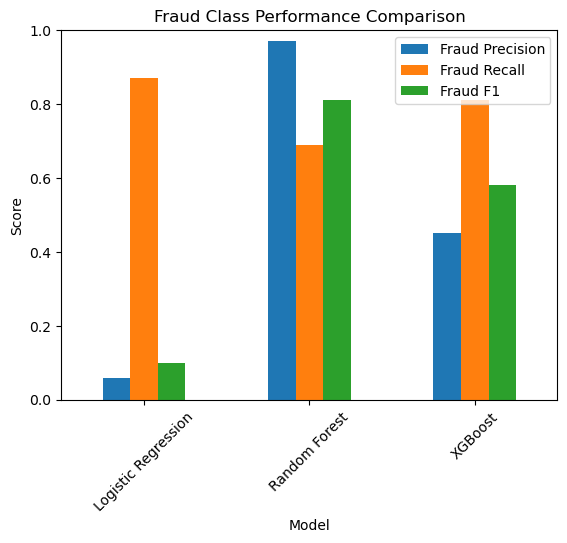

In [414]:
results_table.set_index('Model')[['Fraud Precision', 'Fraud Recall', 'Fraud F1']].plot(kind='bar')

plt.title('Fraud Class Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

The fraud class performance comparison chart highlights the trade-off between precision and recall across models. Logistic Regression has the highest fraud recall but very low precision, meaning it catches many fraud cases but generates many false positives. Random Forest has the highest fraud precision and F1-score, making it highly reliable when flagging fraud. XGBoost provides a balanced performance with strong recall and moderate precision, making it suitable for balanced fraud detection.

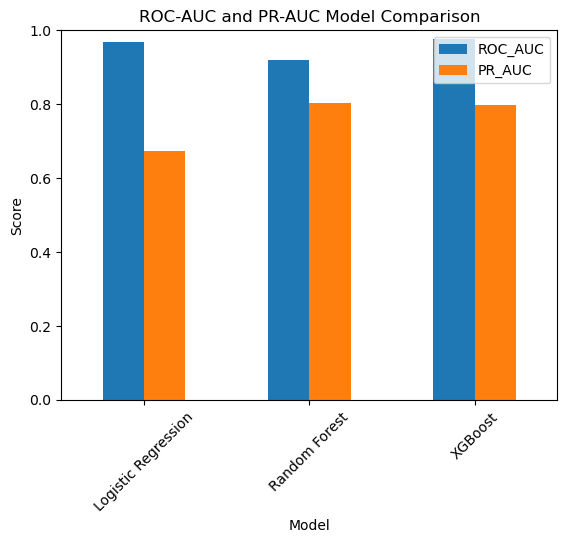

In [415]:
results_table.set_index('Model')[['ROC_AUC', 'PR_AUC']].plot(kind='bar')

plt.title('ROC-AUC and PR-AUC Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

The ROC-AUC and PR-AUC comparison chart shows that XGBoost achieved the highest ROC-AUC score, indicating the strongest overall separation between legitimate and fraudulent transactions. Random Forest achieved the highest PR-AUC score, which is especially important for imbalanced fraud detection. XGBoost achieved a PR-AUC score very close to Random Forest while maintaining higher fraud recall, making it a strong balanced model.

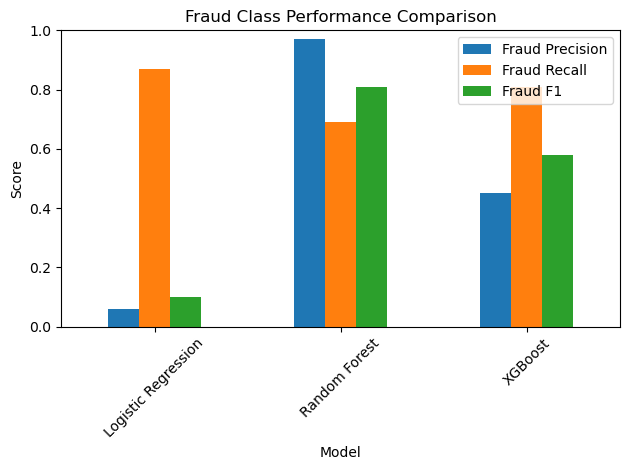

In [416]:
results_table.set_index('Model')[['Fraud Precision', 'Fraud Recall', 'Fraud F1']].plot(kind='bar')

plt.title('Fraud Class Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("fraud_class_performance_comparison.png", dpi=300)
plt.show()

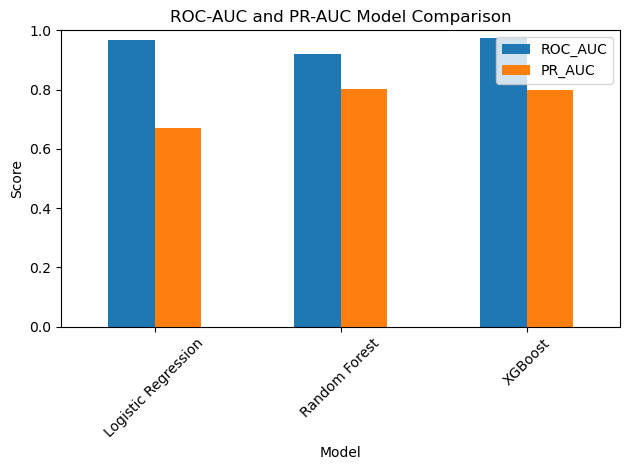

In [417]:
results_table.set_index('Model')[['ROC_AUC', 'PR_AUC']].plot(kind='bar')

plt.title('ROC-AUC and PR-AUC Model Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("roc_pr_auc_model_comparison.png", dpi=300)
plt.show()

In [418]:
import os

os.listdir()

['app.py',
 'data',
 'eda_summary_table.csv',
 'final_model_comparison_results.csv',
 'fraud_class_performance_comparison.png',
 'models',
 'model_comparison_results.csv',
 'notebooks',
 'python',
 'requirements.txt',
 'results',
 'roc_pr_auc_model_comparison.png',
 'sample_transactions_for_app.csv',
 'visuals',
 'xgboost_feature_importance.png',
 'xgboost_fraud_detection_model.pkl']

In [419]:
import joblib

joblib.dump(xgb_model, "xgboost_fraud_detection_model.pkl")

['xgboost_fraud_detection_model.pkl']

The final recommended XGBoost model was saved as `xgboost_fraud_detection_model.pkl`. Saving the model allows it to be reused later for prediction, deployment, or portfolio demonstration without retraining.

In [420]:
loaded_model = joblib.load("xgboost_fraud_detection_model.pkl")

In [421]:
loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 0])

The saved XGBoost model was loaded successfully using joblib. The loaded model was tested on the first five test records and produced valid predictions. This confirms that the model file can be reused for future prediction or deployment.

## Final Project Conclusion

This project developed a machine learning-based credit card fraud detection solution using transaction-level data. The dataset contained 283,726 records after duplicate removal, with only 473 fraudulent transactions, confirming a severe class imbalance.

Exploratory data analysis showed that fraudulent transactions are rare and not always associated with high transaction amounts. Many fraud transactions had small amounts, and zero-amount transactions showed a higher fraud rate than the overall dataset. Time-based analysis also suggested that fraud risk varies across transaction hours.

Three machine learning models were trained and evaluated: Logistic Regression, Random Forest, and XGBoost. Logistic Regression achieved the highest fraud recall but produced too many false positives. Random Forest achieved the highest fraud precision and F1-score, making it useful for conservative fraud detection. XGBoost achieved the highest ROC-AUC and provided a strong balance between fraud detection and false alert control.

Based on the business trade-off, XGBoost was selected as the recommended balanced model, while Random Forest can be considered when minimizing false positives is the top priority.

readme_content = """
# Credit Card Fraud Detection and Risk Scoring Using Machine Learning

## Project Overview

This project focuses on building a machine learning-based credit card fraud detection system. The goal is to identify fraudulent transactions from transaction-level data while balancing fraud detection performance and false alert reduction.

Credit card fraud is a major challenge for banks, fintech companies, payment networks, and merchants. Since fraudulent transactions are rare compared to legitimate transactions, this project deals with a highly imbalanced classification problem.

## Business Problem

Financial institutions process millions of credit card transactions every day. Even a small percentage of fraud can result in financial loss, customer dissatisfaction, and operational burden for fraud investigation teams.

The business objective of this project is to build a fraud detection model that can help identify suspicious transactions and support risk-based decision-making.

## Data Science Problem

This is a supervised binary classification problem.

The target variable is `Class`:

- `0` = Legitimate transaction
- `1` = Fraudulent transaction

## Dataset

Original dataset:

- Total transactions: 284,807
- Fraud transactions: 492
- Legitimate transactions: 284,315
- Original columns: 31

After duplicate removal:

- Total transactions: 283,726
- Fraud transactions: 473
- Legitimate transactions: 283,253

## Key Features

The dataset includes:

- `Time`
- `Amount`
- `V1` to `V28` anonymized transaction features
- `Class` target variable

Additional engineered features:

- `is_zero_amount`
- `transaction_hour`

## Exploratory Data Analysis Findings

Key findings from EDA:

- Fraud transactions represent only about 0.17% of the dataset.
- The dataset is highly imbalanced.
- Most transactions are legitimate.
- Fraud transactions are not always high-value transactions.
- Many fraud transactions are small.
- Zero-amount transactions have a higher fraud rate than the overall dataset.
- Fraud rate varies across transaction hours.

## Models Used

Three machine learning models were trained and compared:

1. Logistic Regression
2. Random Forest
3. XGBoost

## Model Performance

| Model | ROC-AUC | PR-AUC | Fraud Precision | Fraud Recall | Fraud F1 |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.9684 | 0.6721 | 0.06 | 0.87 | 0.10 |
| Random Forest | 0.9193 | 0.8021 | 0.97 | 0.69 | 0.81 |
| XGBoost | 0.9755 | 0.7978 | 0.45 | 0.81 | 0.58 |

## Final Model Selection

XGBoost was selected as the recommended balanced model because it achieved strong fraud recall, better precision than Logistic Regression, and the highest ROC-AUC score.

Random Forest can be considered a conservative alternative when minimizing false positives is the top business priority.

## Business Impact

This fraud detection model can help financial institutions:

- Identify suspicious transactions
- Reduce fraud-related losses
- Support fraud operations teams
- Improve transaction risk monitoring
- Balance fraud prevention with customer experience

## Tools and Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost
- Jupyter Notebook
- Joblib

## Project Files

- `creditfrad.ipynb` — Main notebook
- `eda_summary_table.csv` — EDA summary results
- `final_model_comparison_results.csv` — Final model comparison table
- `fraud_class_performance_comparison.png` — Fraud performance chart
- `roc_pr_auc_model_comparison.png` — ROC-AUC and PR-AUC comparison chart
- `xgboost_fraud_detection_model.pkl` — Saved final model

## Conclusion

This project shows how machine learning can be used to detect fraudulent credit card transactions in a highly imbalanced dataset. The analysis highlights the importance of using fraud-specific evaluation metrics such as precision, recall, F1-score, ROC-AUC, and PR-AUC instead of relying only on accuracy.

The final recommended model, XGBoost, provides a balanced solution for fraud detection by catching a high percentage of fraud cases while reducing false alerts compared with the baseline model.
"""

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully")

In [422]:
import os
os.listdir()

['app.py',
 'data',
 'eda_summary_table.csv',
 'final_model_comparison_results.csv',
 'fraud_class_performance_comparison.png',
 'models',
 'model_comparison_results.csv',
 'notebooks',
 'python',
 'requirements.txt',
 'results',
 'roc_pr_auc_model_comparison.png',
 'sample_transactions_for_app.csv',
 'visuals',
 'xgboost_feature_importance.png',
 'xgboost_fraud_detection_model.pkl']

In [423]:
requirements = """
pandas
numpy
matplotlib
scikit-learn
xgboost
joblib
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully")

requirements.txt created successfully


In [424]:
import os

"requirements.txt" in os.listdir()

True

In [425]:
X_train
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [426]:
print("X_train exists:", "X_train" in globals())
print("xgb_model exists:", "xgb_model" in globals())

X_train exists: True
xgb_model exists: True


In [427]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
14,V14,0.319873
10,V10,0.103847
4,V4,0.043655
8,V8,0.040676
12,V12,0.040190
13,V13,0.030208
20,V20,0.028742
19,V19,0.027509
17,V17,0.026817
22,V22,0.022952


The XGBoost feature importance table shows that the most influential features for fraud prediction include V14, V10, V4, V8, and V12. Since the dataset uses anonymized PCA-transformed features, the original business meaning of these variables is not available. However, the importance scores indicate that these transformed transaction patterns play a major role in identifying fraudulent transactions.

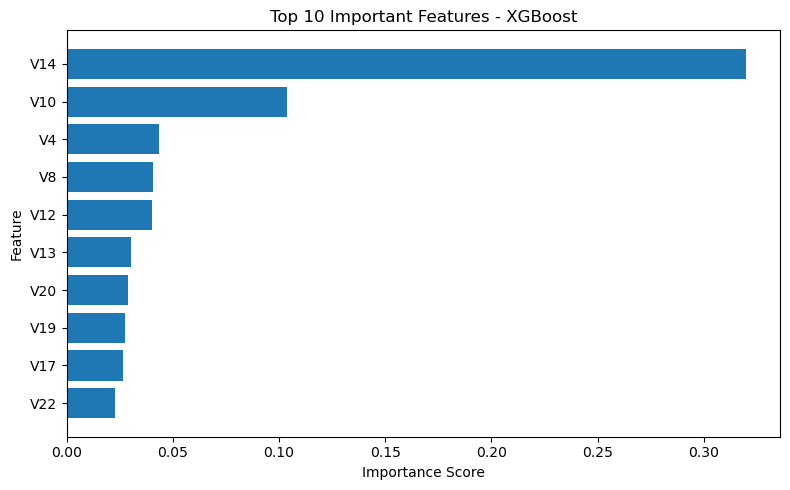

In [428]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=300)
plt.show()

## XGBoost Feature Importance

The feature importance chart shows the top 10 most influential features used by the XGBoost model for fraud prediction. The most important feature is `V14`, followed by `V10`, `V4`, `V8`, and `V12`. Since the original dataset uses anonymized PCA-transformed variables, the original business interpretation of these features is not available. However, the chart confirms that certain transformed transaction patterns play a stronger role in identifying fraudulent transactions.

In [429]:
import os
"xgboost_feature_importance.png" in os.listdir()

True

In [430]:
import sys
!{sys.executable} -m pip install streamlit

In [431]:
import os
print(os.getcwd())

C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection


In [432]:
import os

os.chdir(r"C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection")
print(os.getcwd())

C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection


In [433]:
"app.py" in os.listdir()

True

In [434]:
requirements = """
pandas
numpy
matplotlib
scikit-learn
xgboost
joblib
streamlit
"""

with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt updated successfully")

requirements.txt updated successfully


In [445]:
import os

os.chdir(r"C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection")
print(os.getcwd())

C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection


In [446]:
import os

os.listdir()

['app.py',
 'data',
 'eda_summary_table.csv',
 'final_model_comparison_results.csv',
 'fraud_class_performance_comparison.png',
 'models',
 'model_comparison_results.csv',
 'notebooks',
 'python',
 'requirements.txt',
 'results',
 'roc_pr_auc_model_comparison.png',
 'sample_transactions_for_app.csv',
 'visuals',
 'xgboost_feature_importance.png',
 'xgboost_fraud_detection_model.pkl']

In [447]:
print("app.py exists:", os.path.exists("app.py"))
print("models folder exists:", os.path.exists("models"))
print("model file exists:", os.path.exists("models/xgboost_fraud_detection_model.pkl"))
print("requirements.txt exists:", os.path.exists("requirements.txt"))

app.py exists: True
models folder exists: True
model file exists: True
requirements.txt exists: True


In [448]:
import os

print("Is app.py a file?", os.path.isfile("app.py"))
print("Is app.py a folder?", os.path.isdir("app.py"))

Is app.py a file? True
Is app.py a folder? False


In [439]:
import os

print("app.py exists:", os.path.exists("app.py"))

app.py exists: True


In [459]:
app_code = """
import streamlit as st
import pandas as pd
import joblib

# Page configuration
st.set_page_config(
    page_title="Credit Card Fraud Detection",
    page_icon="💳",
    layout="wide"
)

# Load model
@st.cache_resource
def load_model():
    return joblib.load("models/xgboost_fraud_detection_model.pkl")

model = load_model()

# Sidebar
st.sidebar.title("💳 Fraud Detection App")
st.sidebar.markdown(
    \"\"\"
    This app uses a trained **XGBoost model** to predict whether uploaded credit card transactions are legitimate or fraudulent.

    **Project Focus**
    - Fraud detection
    - Risk scoring
    - Imbalanced classification
    - Business decision support
    \"\"\"
)

st.sidebar.markdown("---")
st.sidebar.subheader("Model Used")
st.sidebar.write("XGBoost Classifier")

st.sidebar.subheader("Business Goal")
st.sidebar.write(
    "Identify suspicious transactions while reducing unnecessary false alerts for genuine customers."
)

# Main title
st.title("💳 Credit Card Fraud Detection & Risk Scoring App")

st.markdown(
    \"\"\"
    This app demonstrates how a machine learning model can support fraud risk decision-making.
    Upload transaction data in CSV format and the model will predict whether transactions are **Legitimate** or **Fraudulent**.
    \"\"\"
)

st.markdown("---")

# Business context
st.subheader("📌 Business Context")
st.info(
    "Credit card fraud detection is a highly imbalanced classification problem. "
    "Fraudulent transactions are rare, but they can cause financial loss, customer dissatisfaction, "
    "and operational burden for fraud investigation teams."
)

# Model performance summary
st.subheader("📊 Final Model Summary")

col1, col2, col3, col4 = st.columns(4)

col1.metric("Selected Model", "XGBoost")
col2.metric("ROC-AUC", "0.9755")
col3.metric("PR-AUC", "0.7978")
col4.metric("Fraud Recall", "81%")

st.markdown("---")

# Upload section
st.subheader("📂 Upload Transaction Data")

uploaded_file = st.file_uploader(
    "Upload a CSV file containing transaction features",
    type=["csv"]
)

if uploaded_file is not None:
    input_data = pd.read_csv(uploaded_file)

    st.success("File uploaded successfully.")

    st.subheader("🔎 Uploaded Data Preview")
    st.dataframe(input_data.head(), use_container_width=True)

    # Drop target column if included
    if "Class" in input_data.columns:
        input_data = input_data.drop("Class", axis=1)

    # Expected model features
    expected_features = model.get_booster().feature_names

    missing_cols = [col for col in expected_features if col not in input_data.columns]
    extra_cols = [col for col in input_data.columns if col not in expected_features]

    if missing_cols:
        st.error(f"The uploaded file is missing required columns: {missing_cols}")
    else:
        # Keep only expected columns in correct order
        input_data = input_data[expected_features]

        # Predictions
        predictions = model.predict(input_data)
        probabilities = model.predict_proba(input_data)[:, 1]

        results = input_data.copy()
        results["Fraud_Probability"] = probabilities
        results["Fraud_Risk_%"] = (probabilities * 100).round(2)
        results["Prediction"] = predictions
        results["Prediction_Label"] = results["Prediction"].map({
            0: "Legitimate",
            1: "Fraudulent"
        })

        def recommended_action(row):
            if row["Prediction"] == 1:
                return "Send to manual review"
            elif row["Fraud_Probability"] >= 0.30:
                return "Monitor closely"
            else:
                return "Approve / Continue monitoring"

        results["Recommended_Action"] = results.apply(recommended_action, axis=1)

        # Summary metrics
        total_transactions = len(results)
        predicted_fraud = int((results["Prediction"] == 1).sum())
        predicted_legitimate = total_transactions - predicted_fraud
        avg_risk = round(results["Fraud_Risk_%"].mean(), 2)

        st.subheader("📈 Prediction Summary")

        m1, m2, m3, m4 = st.columns(4)

        m1.metric("Total Transactions", total_transactions)
        m2.metric("Predicted Fraud", predicted_fraud)
        m3.metric("Predicted Legitimate", predicted_legitimate)
        m4.metric("Average Fraud Risk", f"{avg_risk:.2f}%")

        # Prediction results
        st.subheader("🧾 Prediction Results")

        display_cols = [
            "Fraud_Risk_%",
            "Prediction_Label",
            "Recommended_Action"
        ]

        st.dataframe(results[display_cols].head(50), use_container_width=True)

        # Business recommendation
        st.subheader("💼 Business Recommendation")

        if predicted_fraud > 0:
            st.warning(
                f"{predicted_fraud} transaction(s) were flagged as fraudulent. "
                "Recommended action: send flagged transactions for manual review or additional customer verification."
            )
        elif avg_risk >= 30:
            st.warning(
                "No transaction was directly classified as fraud, but the average fraud risk is elevated. "
                "Recommended action: monitor these transactions closely."
            )
        else:
            st.success(
                "No fraudulent transactions were detected in the uploaded sample. "
                "Recommended action: approve or continue routine monitoring."
            )

        # Download results
        st.subheader("⬇️ Download Prediction Results")

        csv = results.to_csv(index=False).encode("utf-8")

        st.download_button(
            label="Download predictions as CSV",
            data=csv,
            file_name="fraud_prediction_results.csv",
            mime="text/csv"
        )

        # Technical note
        st.markdown("---")
        st.caption(
            "Note: This app is a portfolio demonstration. In a real financial institution, "
            "model thresholds should be selected based on fraud loss, manual review capacity, "
            "regulatory requirements, and customer experience impact."
        )

else:
    st.info("Please upload a CSV file to generate fraud predictions.")
"""

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("Professional app.py updated successfully")

Professional app.py updated successfully


In [456]:
print("Is app.py a file?", os.path.isfile("app.py"))
print("Is app.py a folder?", os.path.isdir("app.py"))

Is app.py a file? True
Is app.py a folder? False


In [442]:
sample_transactions = X_test.head(20)
sample_transactions.to_csv("sample_transactions_for_app.csv", index=False)

print("sample_transactions_for_app.csv created successfully")

sample_transactions_for_app.csv created successfully


In [451]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Make sure we are in the project folder
os.chdir(r"C:\Users\amish\OneDrive\Desktop\portfolio\credit-card-fraud-detection")

# Load original dataset
df = pd.read_csv(r"data\creditcard.csv")

# Add engineered features
df["is_zero_amount"] = (df["Amount"] == 0).astype(int)
df["transaction_hour"] = (df["Time"] // 3600) % 24

# Remove duplicate rows
df_model = df.drop_duplicates()

# Separate features and target
X = df_model.drop("Class", axis=1)
y = df_model["Class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale Time and Amount
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

# Create small sample file for Streamlit app
sample_transactions = X_test.head(20)
sample_transactions.to_csv("sample_transactions_for_app.csv", index=False)

print("sample_transactions_for_app.csv created successfully")

sample_transactions_for_app.csv created successfully


In [452]:
"sample_transactions_for_app.csv" in os.listdir()

True

In [457]:
with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py saved successfully")

app.py saved successfully
